# GSEA barplot

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, LinearSegmentedColormap
import matplotlib.cm as cm
import seaborn as sns
import scipy.stats as stats
import numpy as np
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from mpl_toolkits.axes_grid1 import make_axes_locatable
import os

import matplotlib as mpl
from matplotlib import font_manager

arial_path = "/media/scratch/fy2306/tools/fonts"
font_files = font_manager.findSystemFonts(fontpaths=arial_path)

for file in font_files:
    font_manager.fontManager.addfont(file)
    
mpl.rcParams['font.family'] = 'Arial'

In [14]:
def barplot_subdf(df, id_col, x_col, color_col, cmap, top_number, title):
	if df.empty:
		return

	df = df.sort_values(x_col, ascending=False)
	df = df.head(top_number)
	df = df.sort_values(x_col, ascending=True)

	norm = Normalize(vmin=df[color_col].min(), vmax=df[color_col].max())
	colors = [cmap(norm(val)) for val in df[color_col]]
	df["color"] = colors

	plt.figure(figsize=(6,4))

	plt.barh(df[id_col], df[x_col], color=df["color"])
	# plt.title(title)
	plt.xlabel(r"$-\log_{10}(\mathrm{qvalue})$", fontsize=13)
	plt.yticks(fontsize=12)

	sm = cm.ScalarMappable(norm=norm, cmap=cmap)
	ax = plt.gca()
	ax.spines["top"].set_visible(False)
	ax.spines["right"].set_visible(False)
	plt.colorbar(sm, ax=ax, label=color_col)

	plt.tight_layout()
	plt.show()
	return df

In [15]:
def barplot(df_path, time, id_col="ID", nes_col="NES", q_col="-log10_q"):
	df = pd.read_csv(df_path, sep="\t")
	print(df["NES"].dtype)
	
	df = df[df["qvalue"] < 0.05]	# significance
	df = df.sort_values(by="qvalue", ascending=True)
	df["-log10_q"] = -np.log10(df["qvalue"])

	df_pos = df[df[nes_col] > 0]
	df_neg = df[df[nes_col] < 0]

	cmap_pos = LinearSegmentedColormap.from_list("pos_cmap", ["#FDBFD8", "#FF0066"])
	cmap_neg = LinearSegmentedColormap.from_list("neg_cmap", ["#01A9FC", "#B2E3FA"])

	top_number = 3
	df_pos = barplot_subdf(df_pos, id_col, q_col, nes_col, cmap_pos, top_number, "Positive NES")
	df_neg = barplot_subdf(df_neg, id_col, q_col, nes_col, cmap_neg, top_number, "Negative NES")

	df_neg = df_neg.sort_values(by=q_col, ascending=False)
	df_neg[q_col] = -df_neg[q_col].abs()
	norm_pos = Normalize(vmin=df_pos[nes_col].min(), vmax=df_pos[nes_col].max())
	norm_neg = Normalize(vmin=df_neg[nes_col].min(), vmax=df_neg[nes_col].max())
	df_pos["color"] = [cmap_pos(norm_pos(v)) for v in df_pos[nes_col]]
	df_neg["color"] = [cmap_neg(norm_neg(v)) for v in df_neg[nes_col]]
	n_pos = len(df_pos)
	n_neg = len(df_neg)
	df_pos["_y"] = np.arange(n_pos)[::-1]
	df_neg["_y"] = np.arange(n_neg)[::-1] + n_pos
	df = pd.concat([df_pos, df_neg])
	
	# fig, ax = plt.subplots(figsize=(6, 3))
	fig, ax = plt.subplots(figsize=(6, 4))
	ax.barh(df_neg["_y"], df_neg[q_col], color=df_neg["color"], label="Negative NES")
	ax.barh(df_pos["_y"], df_pos[q_col], color=df_pos["color"], label="Positive NES")

	ax.axvline(0, color="black", linewidth=1)

	max_val = max(df_pos[q_col].max(), df_neg[q_col].abs().max())
	ax.set_xlim(-max_val * 1.2, max_val * 1.1)

	ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"{abs(x):g}"))

	ax.set_xlabel(r"$-\log_{10}(\mathrm{qvalue})$", fontsize=12)
	ax.tick_params(axis="x", labelsize=12)

	ax.spines["top"].set_visible(False)
	ax.spines["right"].set_visible(False)

	sm_pos = cm.ScalarMappable(norm=norm_pos, cmap=cmap_pos)
	sm_neg = cm.ScalarMappable(norm=norm_neg, cmap=cmap_neg)

	divider = make_axes_locatable(ax)

	cax_left = divider.append_axes("left", size="3%", pad=0.30)
	cax_right = divider.append_axes("right", size="3%", pad=0.30)

	cbar_neg = fig.colorbar(sm_neg, cax=cax_left)
	cbar_neg.set_label(f"{nes_col} (neg)", fontsize=10)
	cbar_neg.ax.yaxis.set_major_locator(mticker.MultipleLocator(0.1))
	cbar_neg.ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

	cbar_pos = fig.colorbar(sm_pos, cax=cax_right)
	cbar_pos.set_label(f"{nes_col} (pos)", fontsize=10)
	cbar_pos.ax.yaxis.set_major_locator(mticker.MultipleLocator(0.1))
	cbar_pos.ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

	cax_left.yaxis.set_ticks_position("left")
	cax_left.yaxis.set_label_position("left")

	ax.set_yticks([])
	ax.set_ylabel("")

	x0 = 0
	x_range = ax.get_xlim()[1] - ax.get_xlim()[0]
	pad = 0.01 * x_range

	# df_pos labels: LEFT of 0
	for _, r in df_pos.iterrows():
		ax.text(
			x0 - pad, r["_y"], str(r[id_col]).split("_", 1)[1],
			ha="right", va="center", fontsize=9.5
		)

	# df_neg labels: RIGHT of 0
	for _, r in df_neg.iterrows():
		ax.text(
			x0 + pad, r["_y"], str(r[id_col]).split("_", 1)[1],
			ha="left", va="center", fontsize=9.5
		)

	ax.spines["left"].set_visible(False)

	plt.tight_layout()
	plt.savefig(f"/media/scratch/fy2306/projects/base_editing/plots/ASO/GSEA.{time}.{top_number}.pdf", 
				bbox_inches="tight",
				dpi=300,              
				transparent=True,
				format='pdf')
	plt.show()

float64


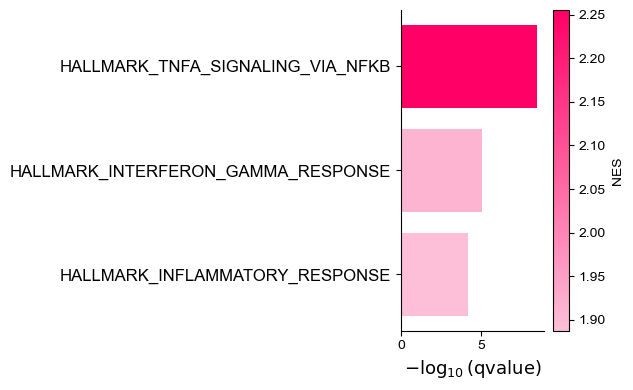

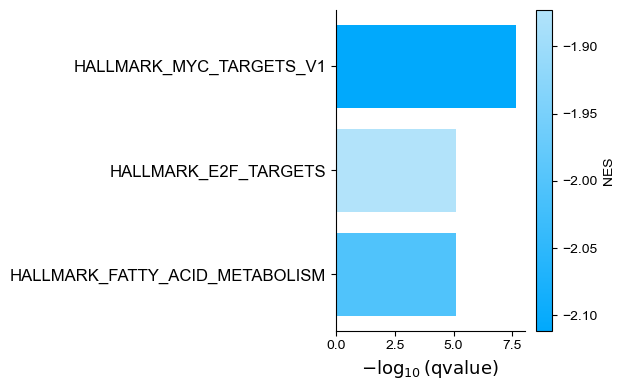

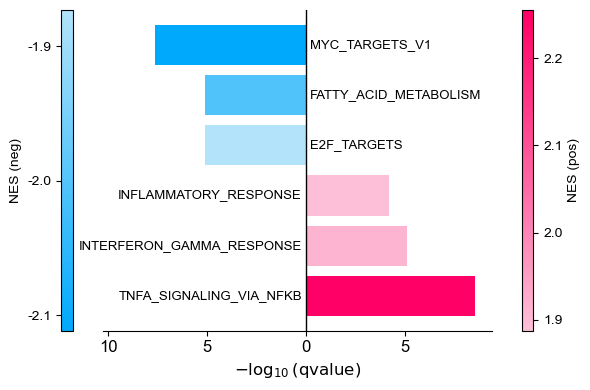

In [16]:
barplot(
	"/media/scratch/fy2306/projects/base_editing/results/ASO_rnaseq_batch_2_outliers/enrichment_72h/gsea_msig_H_std.tsv", 
	"72h"
	)